In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
np.random.seed(42)

n = 50
x = np.linspace(0, 3, n)

true_a = 2.0
true_b = 0.8

# Laplace noise (heavy-tailed)
noise = np.random.laplace(0, 1.0, n)

y = true_a * np.exp(true_b * x) + noise

y[::10] += 10   # strong outliers

In [3]:
def model(params, x):
    a, b = params
    return a * np.exp(b * x)

In [4]:
def least_squares_objective(params, x, y):
    residuals = y - model(params, x)
    return np.sum(residuals**2)

MLE with Laplace noise (L1)

Laplace with location paramter $\mu$:

$p(x \mid \mu, b) = \frac{1}{2b} \exp\left(-\frac{|x - \mu|}{b}\right)$

Noise model:

$p(\varepsilon) = \frac{1}{2b} \exp\left(-\frac{|\varepsilon|}{b}\right)$

Induced data likelihood:

$p(y_i \mid x_i, \theta) = \frac{1}{2b} \exp\left(-\frac{|y_i - f(x_i;\theta)|}{b}\right)$

$\mathcal{L}(\theta) = \prod_{i=1}^n \frac{1}{2b} \exp\left(-\frac{|y_i - f(x_i;\theta)|}{b}\right)$

$\log \mathcal{L}(\theta) = n \log\left(\frac{1}{2b}\right) - \frac{1}{b} \sum_{i=1}^n |y_i - f(x_i;\theta)|$

$\hat{\theta} = \arg\min_{\theta} \sum_{i=1}^n \lvert y_i - f(x_i;\theta) \rvert$

In [5]:
def neg_log_likelihood(params, x, y):
    residuals = y - model(params, x)
    return np.sum(np.abs(residuals))

MAP (assuming Gaussian prior on parameters here)

* Laplace likelihood → gives you L1 data term
* Gaussian prior → gives you L2 regularization

These are independent choices.

One could also use Laplace prior.

MAP = MLE loss + regularization term,

and the type of regularization is determined by the prior, not the noise model.

In [6]:
def neg_log_posterior(params, x, y, tau):
    nll = neg_log_likelihood(params, x, y)
    lambda_reg = 1 / tau**2
    prior = lambda_reg * np.sum((params)**2)
    return nll + prior

optimization

In [7]:
init_params = np.array([1.0, 0.1])  # initial guess

# Least Squares
res_ls = minimize(least_squares_objective, init_params, args=(x, y))
params_ls = res_ls.x

# MLE
res_mle = minimize(neg_log_likelihood, init_params, args=(x, y))
params_mle = res_mle.x

# MAP
tau = 0.3 # strong regularization
res_map = minimize(neg_log_posterior, init_params, args=(x, y, tau))
params_map = res_map.x

In [8]:
print("True parameters:")
print(f"a = {true_a}, b = {true_b}\n")

print("Least Squares estimate:")
print(params_ls)

print("\nMaximum Likelihood estimate:")
print(params_mle)

print("\nMAP estimate:")
print(params_map)

True parameters:
a = 2.0, b = 0.8

Least Squares estimate:
[2.73933527 0.68814431]

Maximum Likelihood estimate:
[1.975551   0.80268318]

MAP estimate:
[1.4582964  0.91202343]


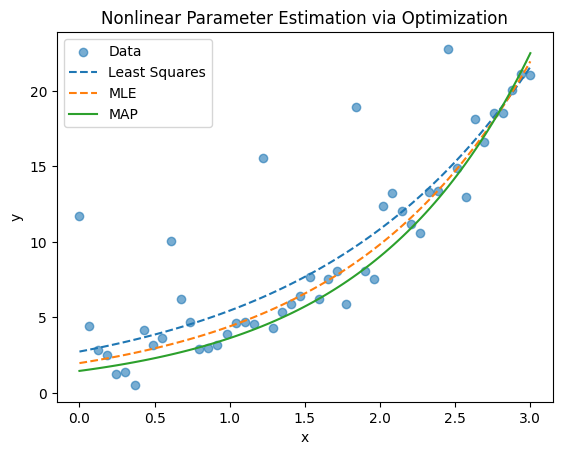

In [9]:
x_plot = np.linspace(0, 3, 100)

y_ls = model(params_ls, x_plot)
y_mle = model(params_mle, x_plot)
y_map = model(params_map, x_plot)

plt.scatter(x, y, label="Data", alpha=0.6)
plt.plot(x_plot, y_ls, label="Least Squares", linestyle="--")
plt.plot(x_plot, y_mle, label="MLE", linestyle="--")
plt.plot(x_plot, y_map, label="MAP")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear Parameter Estimation via Optimization")
plt.show()